# Evaluating Local HuggingFace Models for Text2Cypher
## Google BLEU & Exact Match on neo4j/text2cypher-2024v1

This notebook evaluates the following local models on the `neo4j/text2cypher-2024v1` dataset:

| Model | HuggingFace ID |
|-------|----------------|
| Stable Code Instruct 3B | `stabilityai/stable-code-instruct-3b` |
| Llama-3-8B-Instruct | `meta-llama/Meta-Llama-3-8B-Instruct` |
| CodeLlama-13B-Instruct | `codellama/CodeLlama-13b-Instruct-hf` |
| Llama-3.1-8B-Instruct | `meta-llama/Llama-3.1-8B-Instruct` |
| CodeLlama-7B-Instruct | `codellama/CodeLlama-7b-Instruct-hf` |
| Gemma-2-9B-IT | `google/gemma-2-9b-it` |
| CodeGemma-7B-IT | `google/codegemma-7b-it` |

**Metrics:**
- **Google BLEU (GLEU):** Sentence-level BLEU variant from `nltk` that correlates better with human judgments.
- **Exact Match:** Binary score — 1 if the generated Cypher exactly matches the reference, 0 otherwise.

**Requirements:** GPU with at least 16 GB VRAM (24+ GB recommended). Models are loaded in 4-bit quantization.

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import sys, torch
print(sys.executable)
print(torch.__version__, torch.version.cuda, torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CUDA not available in this kernel")

c:\Users\Aaron\Desktop\Repos\text2cypher\.venv\Scripts\python.exe
2.10.0+cu128 12.8 True
NVIDIA GeForce RTX 5080


In [2]:
from getpass import getpass
import os
from huggingface_hub import login

# Prompts securely (doesn't print token)
os.environ["HUGGINGFACE_HUB_TOKEN"] = getpass("Enter Hugging Face token: ").strip()

# Auth for this kernel session
login(token=os.environ["HUGGINGFACE_HUB_TOKEN"], add_to_git_credential=False)
print("HF login set for current notebook session.")

c:\Users\Aaron\Desktop\Repos\text2cypher\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF login set for current notebook session.


In [3]:
%pip install -q datasets transformers accelerate bitsandbytes nltk seaborn matplotlib pandas tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import gc
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk.translate.gleu_score import sentence_gleu
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from tqdm.auto import tqdm

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

True

## Load Dataset

In [5]:
ds = load_dataset("neo4j/text2cypher-2024v1")
print(ds)
print("\nColumns:", ds["train"].column_names)
print("Number of samples:", len(ds["train"]))
# test first question
ds["train"][0]

DatasetDict({
    train: Dataset({
        features: ['question', 'schema', 'cypher', 'data_source', 'instance_id', 'database_reference_alias'],
        num_rows: 39554
    })
    test: Dataset({
        features: ['question', 'schema', 'cypher', 'data_source', 'instance_id', 'database_reference_alias'],
        num_rows: 4833
    })
})

Columns: ['question', 'schema', 'cypher', 'data_source', 'instance_id', 'database_reference_alias']
Number of samples: 39554


{'question': 'Which 3 countries have the most entities linked as beneficiaries in filings?',
 'schema': 'Node properties:\n- **Country**\n  - `location`: POINT \n  - `code`: STRING Example: "AFG"\n  - `name`: STRING Example: "Afghanistan"\n  - `tld`: STRING Example: "AF"\n- **Filing**\n  - `begin`: DATE_TIME Min: 2000-02-08T00:00:00Z, Max: 2017-09-05T00:00:00Z\n  - `end`: DATE_TIME Min: 2000-02-08T00:00:00Z, Max: 2017-11-03T00:00:00Z\n  - `originator_bank_id`: STRING Example: "cimb-bank-berhad"\n  - `sar_id`: STRING Example: "3297"\n  - `beneficiary_bank`: STRING Example: "Barclays Bank Plc"\n  - `filer_org_name_id`: STRING Example: "the-bank-of-new-york-mellon-corp"\n  - `originator_bank_country`: STRING Example: "Singapore"\n  - `beneficiary_bank_country`: STRING Example: "United Kingdom"\n  - `filer_org_name`: STRING Example: "The Bank of New York Mellon Corp."\n  - `originator_iso`: STRING Example: "SGP"\n  - `beneficiary_bank_id`: STRING Example: "barclays-bank-plc-london-england-

## Configuration

Adjust `NUM_SAMPLES` to control how many examples to evaluate (set to `None` for the full dataset).

In [6]:
# Number of samples to evaluate per model (set to None for full dataset)
NUM_SAMPLES = 200

# Max new tokens to generate
MAX_NEW_TOKENS = 256
    #"CodeLlama-13B-Instruct": "codellama/CodeLlama-13b-Instruct-hf",
# Models to evaluate
MODELS = {
    "StableCode-Instruct-3B": "stabilityai/stable-code-instruct-3b",
    "Llama-3-8B-Instruct": "meta-llama/Meta-Llama-3-8B-Instruct",
    "Llama-3.1-8B-Instruct": "meta-llama/Llama-3.1-8B-Instruct",
    "CodeLlama-7B-Instruct": "codellama/CodeLlama-7b-Instruct-hf",
    "Gemma-2-9B-IT": "google/gemma-2-9b-it",
    "CodeGemma-7B-IT": "google/codegemma-7b-it",
}

# Select evaluation subset
eval_dataset = ds["train"].shuffle(seed=42)
if NUM_SAMPLES is not None:
    eval_dataset = eval_dataset.select(range(min(NUM_SAMPLES, len(eval_dataset))))

print(f"Evaluating on {len(eval_dataset)} samples per model")

Evaluating on 200 samples per model


## Metric Functions

In [7]:
def compute_exact_match(prediction: str, reference: str) -> int:
    """Return 1 if the prediction exactly matches the reference (after stripping whitespace), 0 otherwise."""
    return int(prediction.strip() == reference.strip())


def compute_gleu(prediction: str, reference: str) -> float:
    """Compute Google BLEU (GLEU) score between prediction and reference.
    
    Tokenizes on whitespace to produce token-level n-gram overlap.
    Returns a float in [0, 1].
    """
    ref_tokens = reference.strip().split()
    pred_tokens = prediction.strip().split()
    if len(ref_tokens) == 0 and len(pred_tokens) == 0:
        return 1.0
    if len(ref_tokens) == 0 or len(pred_tokens) == 0:
        return 0.0
    try:
        return sentence_gleu([ref_tokens], pred_tokens)
    except Exception:
        return 0.0


# Quick sanity check
assert compute_exact_match("MATCH (n) RETURN n", "MATCH (n) RETURN n") == 1
assert compute_exact_match("MATCH (n) RETURN n", "MATCH (m) RETURN m") == 0
print("GLEU identical:", compute_gleu("MATCH (n) RETURN n", "MATCH (n) RETURN n"))
print("GLEU different:", compute_gleu("MATCH (n) RETURN n", "MATCH (m) RETURN m"))
print("Metrics OK")

GLEU identical: 1.0
GLEU different: 0.2
Metrics OK


## Prompt Builder

Build a text2cypher prompt from each dataset sample. The dataset has `question`, `schema`, and `cypher` columns.

In [8]:
SYSTEM_MESSAGE = "Given an input question, convert it to a Cypher query. No pre-amble."

def build_messages(question: str, schema: str) -> list:
    """Build chat messages for text2cypher generation."""
    return [
        {"role": "system", "content": SYSTEM_MESSAGE},
        {
            "role": "user",
            "content": (
                f"Based on the Neo4j graph schema below, write a Cypher query that would "
                f"answer the user's question.\n"
                f"Return only the Cypher statement, no backticks, nothing else.\n\n"
                f"{schema}\n\n"
                f"Question: {question}\n"
                f"Cypher query:"
            ),
        },
    ]


# Preview a prompt
sample = eval_dataset[0]
msgs = build_messages(sample["question"], sample["schema"])
for m in msgs:
    print(f"[{m['role']}]\n{m['content'][:200]}...\n")

[system]
Given an input question, convert it to a Cypher query. No pre-amble....

[user]
Based on the Neo4j graph schema below, write a Cypher query that would answer the user's question.
Return only the Cypher statement, no backticks, nothing else.

Node properties:
- **Movie**
  - `titl...



## Model Loading & Generation Utilities

In [9]:
def load_model_and_tokenizer(model_id: str):
    """Load a model in 4-bit quantization with its tokenizer."""
    print(f"Loading {model_id}...")
    
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
    )
    
    tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
        torch_dtype=torch.bfloat16,
    )
    model.eval()
    
    print(f"Loaded {model_id} successfully.")
    return model, tokenizer


def unload_model(model, tokenizer):
    """Free GPU memory."""
    del model
    del tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def generate_cypher(model, tokenizer, question: str, schema: str) -> str:
    """Generate a Cypher query from a question and schema."""
    messages = build_messages(question, schema)
    
    # Try using chat template if available
    try:
        input_text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
    except Exception:
        # Fallback: concatenate messages as plain text
        input_text = f"{messages[0]['content']}\n\n{messages[1]['content']}\n"
    
    inputs = tokenizer(input_text, return_tensors="pt", truncation=True, max_length=2048)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.pad_token_id,
        )
    
    # Decode only the new tokens
    input_length = inputs["input_ids"].shape[1]
    generated_tokens = outputs[0][input_length:]
    result = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()
    
    # Clean up: remove markdown backticks if present
    if result.startswith("```cypher"):
        result = result[len("```cypher"):]
    elif result.startswith("```"):
        result = result[3:]
    if result.endswith("```"):
        result = result[:-3]
    
    return result.strip()

## Run Evaluation

Each model is loaded one at a time, evaluated on the dataset, and then unloaded to free memory.

In [10]:
all_results = {}  # model_name -> {"gleu": [...], "exact_match": [...], "predictions": [...]}

for model_name, model_id in MODELS.items():
    print(f"\n{'='*60}")
    print(f"Evaluating: {model_name} ({model_id})")
    print(f"{'='*60}")
    
    try:
        model, tokenizer = load_model_and_tokenizer(model_id)
    except Exception as e:
        print(f"Failed to load {model_name}: {e}")
        all_results[model_name] = {"gleu": [], "exact_match": [], "predictions": [], "error": str(e)}
        continue
    
    gleu_scores = []
    exact_matches = []
    predictions = []
    
    for i in tqdm(range(len(eval_dataset)), desc=model_name):
        sample = eval_dataset[i]
        reference = sample["cypher"]
        
        try:
            prediction = generate_cypher(model, tokenizer, sample["question"], sample["schema"])
        except Exception as e:
            prediction = ""
            print(f"  Generation error on sample {i}: {e}")
        
        gleu = compute_gleu(prediction, reference)
        em = compute_exact_match(prediction, reference)
        
        gleu_scores.append(gleu)
        exact_matches.append(em)
        predictions.append(prediction)
    
    all_results[model_name] = {
        "gleu": gleu_scores,
        "exact_match": exact_matches,
        "predictions": predictions,
    }
    
    avg_gleu = np.mean(gleu_scores) if gleu_scores else 0
    avg_em = np.mean(exact_matches) if exact_matches else 0
    print(f"\n{model_name} -- Avg GLEU: {avg_gleu:.4f} | Avg Exact Match: {avg_em:.4f}")
    
    # Free memory before loading next model
    unload_model(model, tokenizer)

print("\nAll evaluations complete.")


Evaluating: StableCode-Instruct-3B (stabilityai/stable-code-instruct-3b)
Loading stabilityai/stable-code-instruct-3b...


`torch_dtype` is deprecated! Use `dtype` instead!
c:\Users\Aaron\Desktop\Repos\text2cypher\.venv\Lib\site-packages\accelerate\utils\modeling.py:804: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  _ = torch.tensor([0], device=i)
Loading weights: 100%|██████████| 356/356 [00:04<00:00, 82.58it/s]


Loaded stabilityai/stable-code-instruct-3b successfully.


StableCode-Instruct-3B: 100%|██████████| 200/200 [12:28<00:00,  3.74s/it]



StableCode-Instruct-3B -- Avg GLEU: 0.0603 | Avg Exact Match: 0.0000

Evaluating: Llama-3-8B-Instruct (meta-llama/Meta-Llama-3-8B-Instruct)
Loading meta-llama/Meta-Llama-3-8B-Instruct...


...


Gemma-2-9B-IT -- Avg GLEU: 0.2694 | Avg Exact Match: 0.0100

Evaluating: CodeGemma-7B-IT (google/codegemma-7b-it)
Loading google/codegemma-7b-it...


Loading weights: 100%|██████████| 254/254 [00:17<00:00, 14.19it/s]


Loaded google/codegemma-7b-it successfully.


CodeGemma-7B-IT: 100%|██████████| 200/200 [34:50<00:00, 10.45s/it]



CodeGemma-7B-IT -- Avg GLEU: 0.2564 | Avg Exact Match: 0.0000

All evaluations complete.


## Results Summary

In [11]:
# Build summary table
summary_rows = []
for model_name, results in all_results.items():
    if "error" in results:
        summary_rows.append({
            "Model": model_name,
            "Avg GLEU": None,
            "Avg Exact Match": None,
            "Num Samples": 0,
            "Error": results["error"],
        })
    else:
        summary_rows.append({
            "Model": model_name,
            "Avg GLEU": np.mean(results["gleu"]),
            "Avg Exact Match": np.mean(results["exact_match"]),
            "Num Samples": len(results["gleu"]),
            "Error": None,
        })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Model,Avg GLEU,Avg Exact Match,Num Samples,Error
0,StableCode-Instruct-3B,0.060281,0.000,200,None
1,Llama-3-8B-Instruct,0.240587,0.005,200,None
2,Llama-3.1-8B-Instruct,0.233077,0.005,200,None
3,CodeLlama-7B-Instruct,0.228291,0.005,200,None
4,Gemma-2-9B-IT,0.269429,0.010,200,None
5,CodeGemma-7B-IT,0.256429,0.000,200,None


## Visualization

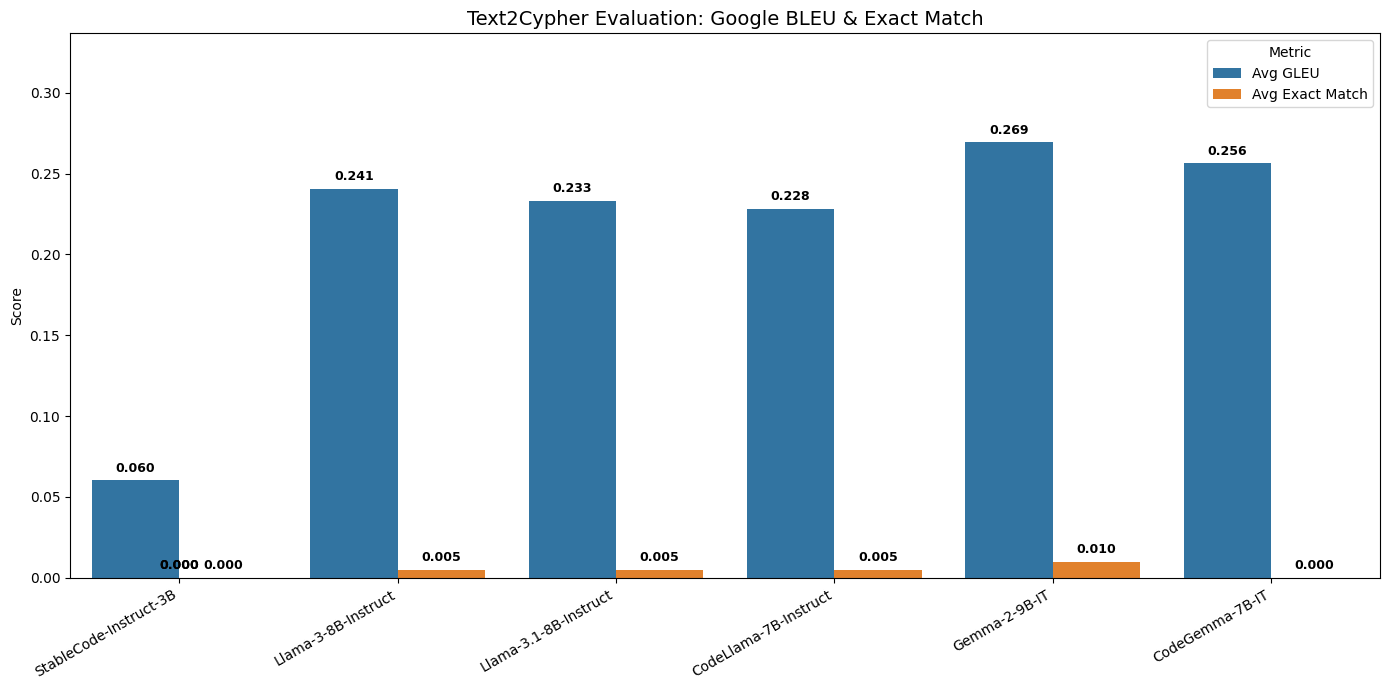

In [12]:
# Filter out models that failed to load
plot_df = summary_df.dropna(subset=["Avg GLEU", "Avg Exact Match"]).copy()

if plot_df.empty:
    print("No models were successfully evaluated.")
else:
    melted = plot_df.melt(
        id_vars=["Model"],
        value_vars=["Avg GLEU", "Avg Exact Match"],
        var_name="Metric",
        value_name="Score",
    )
    
    fig, ax = plt.subplots(figsize=(14, 7))
    barplot = sns.barplot(x="Model", y="Score", hue="Metric", data=melted, ax=ax)
    
    # Annotate bars with values
    for p in barplot.patches:
        height = p.get_height()
        if not np.isnan(height):
            barplot.annotate(
                f"{height:.3f}",
                (p.get_x() + p.get_width() / 2.0, height),
                ha="center", va="bottom",
                fontsize=9, fontweight="bold",
                xytext=(0, 4), textcoords="offset points",
            )
    
    ax.set_title("Text2Cypher Evaluation: Google BLEU & Exact Match", fontsize=14)
    ax.set_ylabel("Score")
    ax.set_xlabel("")
    ax.set_ylim(0, min(1.0, melted["Score"].max() * 1.25))
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Metric")
    plt.tight_layout()
    plt.show()

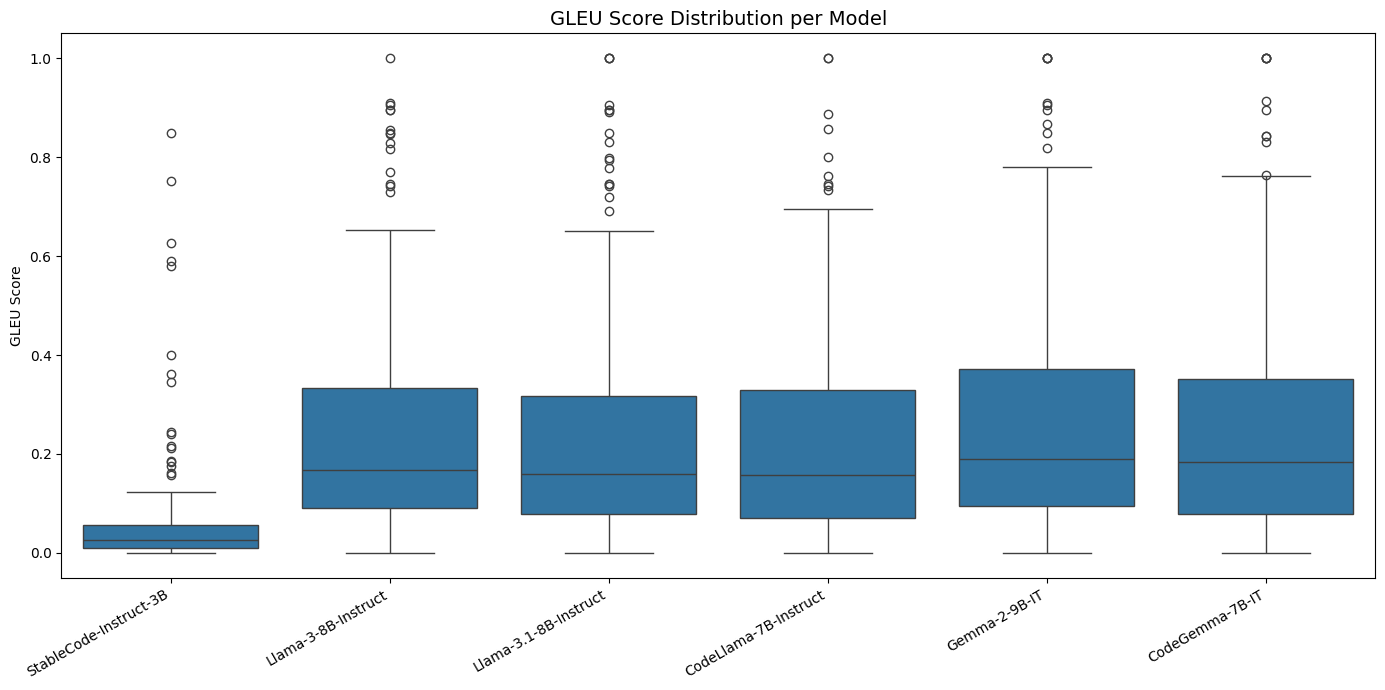

In [13]:
# GLEU distribution per model (box plot)
gleu_rows = []
for model_name, results in all_results.items():
    if "error" not in results:
        for score in results["gleu"]:
            gleu_rows.append({"Model": model_name, "GLEU": score})

if gleu_rows:
    gleu_df = pd.DataFrame(gleu_rows)
    fig, ax = plt.subplots(figsize=(14, 7))
    sns.boxplot(x="Model", y="GLEU", data=gleu_df, ax=ax)
    ax.set_title("GLEU Score Distribution per Model", fontsize=14)
    ax.set_ylabel("GLEU Score")
    ax.set_xlabel("")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No GLEU data to plot.")

## Sample Predictions

Preview generated Cypher vs reference for the first few samples.

In [14]:
NUM_PREVIEW = 5

for i in range(min(NUM_PREVIEW, len(eval_dataset))):
    sample = eval_dataset[i]
    print(f"\n{'='*60}")
    print(f"Sample {i+1}")
    print(f"Question: {sample['question']}")
    print(f"Reference Cypher: {sample['cypher']}")
    print("-" * 40)
    for model_name, results in all_results.items():
        if "error" not in results and i < len(results["predictions"]):
            pred = results["predictions"][i]
            gleu = results["gleu"][i]
            em = results["exact_match"][i]
            print(f"  {model_name}:")
            print(f"    Prediction: {pred}")
            print(f"    GLEU: {gleu:.4f} | EM: {em}")


Sample 1
Question: What are the roles of persons acting in movies with a tagline mentioning 'end'?
Reference Cypher: MATCH (p:Person)-[r:ACTED_IN]->(m:Movie) WHERE m.tagline CONTAINS 'end' RETURN p.name, r.roles
----------------------------------------
  StableCode-Instruct-3B:
    Prediction: Cypher query:
```
MATCH (m:Movie)-[:ACTED_IN]->(p:Person)
WHERE m.tagline CONTAINS 'end'
RETURN p.roles
```
This query will return the roles of persons that are acting in movies which have a tagline mentioning 'end'. The `MATCH` command is used to find the relationship between the person and the movie, the `WHERE` clause is used to filter out the movies with a tagline containing the word 'end', and the `RETURN` statement is used to return the roles of the persons.<|im_end|>
    GLEU: 0.0503 | EM: 0
  Llama-3-8B-Instruct:
    Prediction: MATCH (p:Person)-[:ACTED_IN]->(m:Movie) 
WHERE m.tagline CONTAINS 'end' 
UNWIND p.roles AS role 
RETURN p.name, role;
    GLEU: 0.3043 | EM: 0
  Llama-3.1-8B-Ins

## Save Results to CSV

In [ ]:
# Save detailed per-sample results
detail_rows = []
for i in range(len(eval_dataset)):
    sample = eval_dataset[i]
    row = {
        "sample_idx": i,
        "question": sample["question"],
        "reference_cypher": sample["cypher"],
    }
    for model_name, results in all_results.items():
        if "error" not in results and i < len(results["predictions"]):
            row[f"{model_name}_prediction"] = results["predictions"][i]
            row[f"{model_name}_gleu"] = results["gleu"][i]
            row[f"{model_name}_em"] = results["exact_match"][i]
    detail_rows.append(row)

detail_df = pd.DataFrame(detail_rows)
detail_df.to_csv("evaluation_results_gleu_em.csv", index=False)
print(f"Saved detailed results to evaluation_results_gleu_em.csv ({len(detail_df)} rows)")

# Save summary
summary_df.to_csv("evaluation_summary_gleu_em.csv", index=False)
print("Saved summary to evaluation_summary_gleu_em.csv")

Saved detailed results to evaluation_results_gleu_em.csv (200 rows)
Saved summary to evaluation_summary_gleu_em.csv


: 